Phase 1:

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

os.makedirs("images", exist_ok=True)

In [3]:
df = pd.read_csv("/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


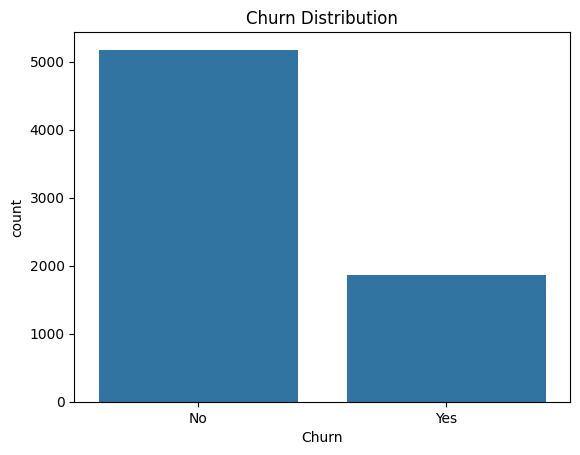

In [6]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")

plt.savefig(
    "images/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

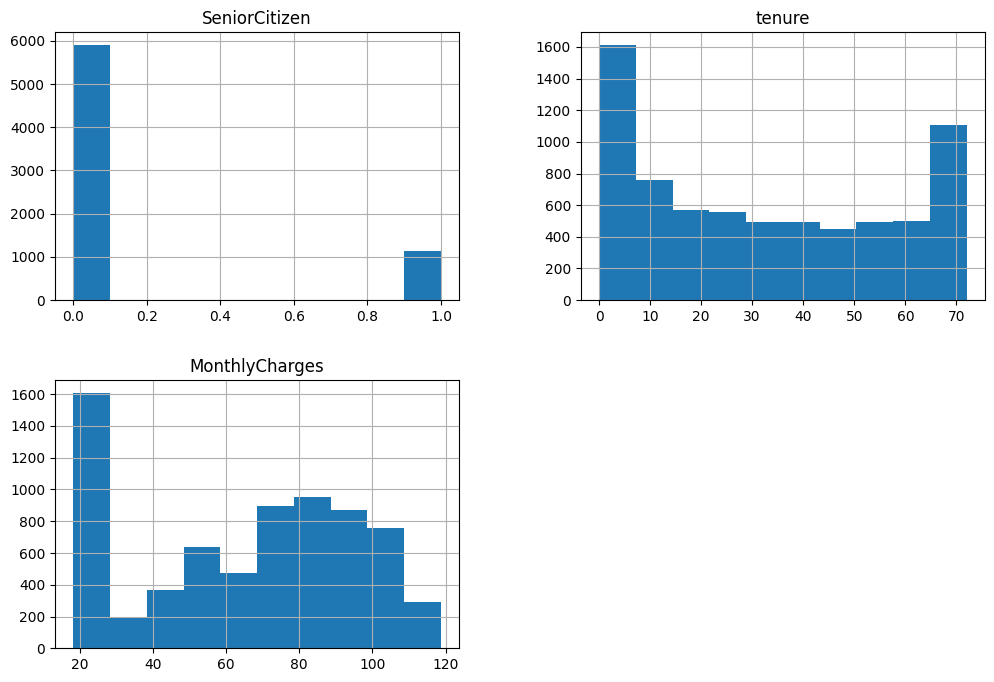

In [7]:
df.hist(figsize=(12,8))

plt.savefig(
    "images/histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

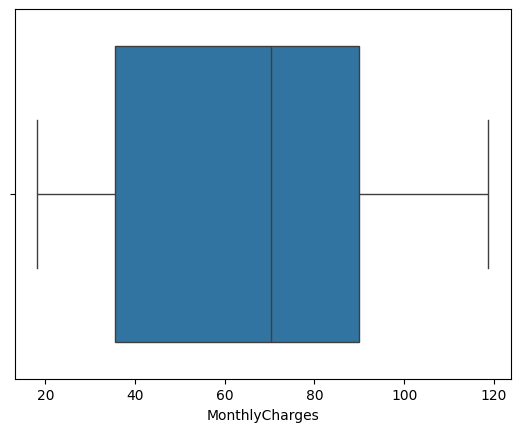

In [8]:
sns.boxplot(x=df['MonthlyCharges'])

plt.savefig(
    "images/boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

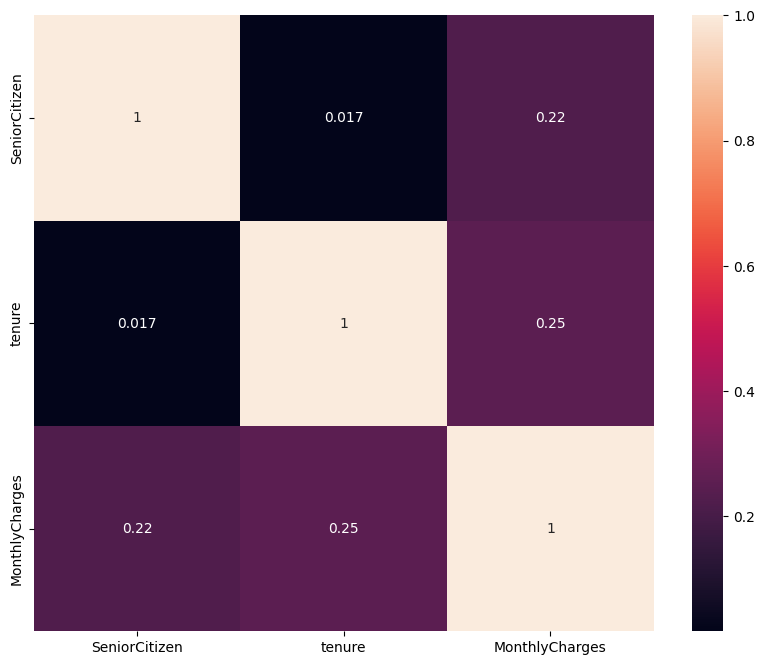

In [9]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)

plt.savefig(
    "images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Phase 2:

In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
df.dropna(inplace=True)

In [12]:
df['Churn'] = df['Churn'].map({
    'Yes':1,
    'No':0
})

In [13]:
df = pd.get_dummies(df, drop_first=True)

In [14]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,1,29.85,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,45,42.30,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
X = df.drop("Churn", axis = 1)
y = df["Churn"]

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Phase 3:

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty="l2", C=1.0, solver='lbfgs', max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

**Phase 4:**

In [19]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:,1]

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1019   17]
 [ 319   54]]


### Interpreting the Confusion Matrix

The confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows the visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class, or vice versa.

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
classif_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Classification Report: {classif_report}")

Accuracy: 0.7615330021291696
Precision: 0.7605633802816901
Recall: 0.1447721179624665
F1 Score: 0.24324324324324326
Classification Report:               precision    recall  f1-score   support

           0       0.76      0.98      0.86      1036
           1       0.76      0.14      0.24       373

    accuracy                           0.76      1409
   macro avg       0.76      0.56      0.55      1409
weighted avg       0.76      0.76      0.70      1409



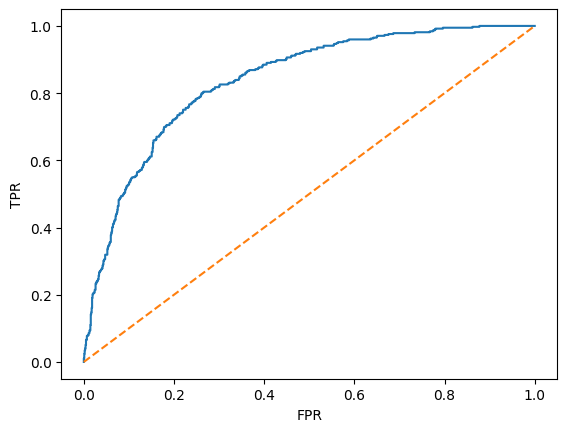

ROC AUC Score: 0.8371145465649488


In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")

plt.savefig(
    "images/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {roc_auc}")

**Phase 5: Interpretation**

In [23]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
)
coefficients.head()

,Feature,Coefficient
0,SeniorCitizen,0.175477
1,tenure,-0.589423
2,MonthlyCharges,0.157617
3,customerID_0003-MKNFE,-0.034588
4,customerID_0004-TLHLJ,0.078132


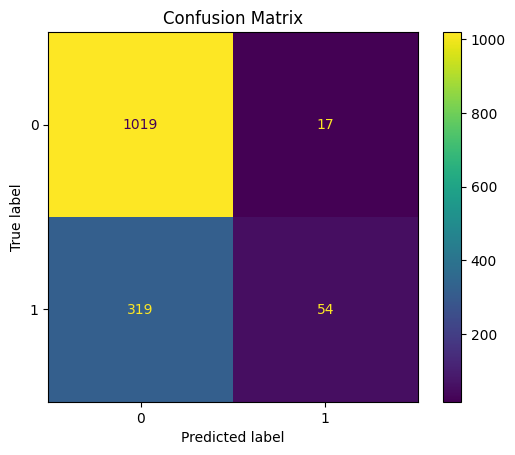

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix")

plt.savefig(
    "images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# verifying the saved images

print(os.listdir("images"))

['confusion_matrix.png', 'boxplot.png', 'churn_distribution.png', 'roc_curve.png', 'correlation_heatmap.png', 'histograms.png']


In [26]:
from google.colab import files

files.download("images/churn_distribution.png")
files.download("images/correlation_heatmap.png")
files.download("images/roc_curve.png")
files.download("images/confusion_matrix.png")
files.download("images/histograms.png")
files.download("images/boxplot.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
files.download("images/roc_curve.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>